In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Cost function을 파이썬으로 구현

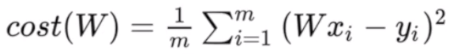

W를 -3부터 5까지 바꿔가면서 cost를 계산해본다.

In [ ]:
X = [1, 2, 3]
Y = [1, 2, 3]

def cost_func(W, X, Y):         # W,X,Y를 cost를 출력한다. 
    c = 0
    for i in range(len(X)):
        c += (W * X[i] - Y[i]) ** 2
    return c / len(X)

print(f'   W     cost')

w_val = []
cost_val = []
for feed_W in np.linspace(-3, 5, num=15):   # W를 -3부터 5까지 바꿔가면서 cost를 계산해본다.
    curr_cost = cost_func(feed_W, X, Y)
    w_val.append(feed_W)
    cost_val.append(curr_cost)
    print(f'{feed_W:.3f} {curr_cost:.5f}')

   W     cost
-3.000 74.66667
-2.429 54.85714
-1.857 38.09524
-1.286 24.38095
-0.714 13.71429
-0.143 6.09524
0.429 1.52381
1.000 0.00000
1.571 1.52381
2.143 6.09524
2.714 13.71429
3.286 24.38095
3.857 38.09524
4.429 54.85714
5.000 74.66667


위의 W와 cost를 그래프로 찍어보면 아래와 같다.

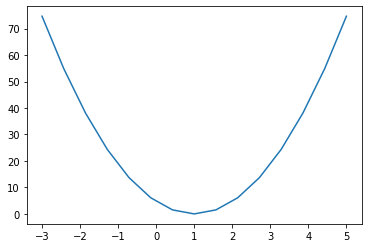

In [ ]:
plt.plot(w_val, cost_val)
plt.show()

# TF로 구현

In [ ]:
X = np.array([1, 2, 3])
Y = np.array([1, 2, 3])

def cost_func(W, X, Y):
    hypothesis = X * W
    return tf.reduce_mean(tf.square(hypothesis - Y))

W_values = np.linspace(-3, 5, num=15)
cost_values = []

for feed_W in W_values:
    curr_cost = cost_func(feed_W, X, Y)
    cost_values.append(curr_cost)
    print(f'{feed_W:.3f} {curr_cost:.5f}')

-3.000 74.66667
-2.429 54.85714
-1.857 38.09524
-1.286 24.38095
-0.714 13.71429
-0.143 6.09524
0.429 1.52381
1.000 0.00000
1.571 1.52381
2.143 6.09524
2.714 13.71429
3.286 24.38095
3.857 38.09524
4.429 54.85714
5.000 74.66667


# Gradient descent를 구현

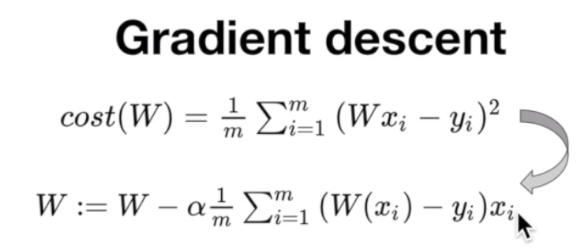

In [44]:
tf.random.set_seed(0)

x_data = [1,2,3]
y_data = [1,2,3]

# W = tf.Variable(tf.random.normal([1], -100, 100.))
W = tf.Variable(5.0)

for step in range(200):
    hypothesis = W * x_data
    cost = tf.reduce_mean(tf.square(hypothesis - y_data))

    # Gradient descent
    alpha = 0.01
    gradient = tf.reduce_mean((W * x_data - y_data) * x_data) # W의 기울기
    descent = W - alpha * gradient # 새로운 W 값
    W.assign(descent) # W에 할당

    if step % 10 == 0:
        print(f'{step} {cost.numpy():.5f} {W.numpy():.4f}')

0 74.66666 4.8133
10 28.70929 3.3646
20 11.03870 2.4662
30 4.24438 1.9092
40 1.63196 1.5638
50 0.62749 1.3496
60 0.24127 1.2168
70 0.09277 1.1344
80 0.03567 1.0833
90 0.01371 1.0517
100 0.00527 1.0320
110 0.00203 1.0199
120 0.00078 1.0123
130 0.00030 1.0076
140 0.00012 1.0047
150 0.00004 1.0029
160 0.00002 1.0018
170 0.00001 1.0011
180 0.00000 1.0007
190 0.00000 1.0004
